# Applied Single product model 
This notebook contains the code that applies the single product model to indian farmer survey:
[Link to survey](https://www-sciencedirect-com.vu-nl.idm.oclc.org/science/article/pii/S2352340922008319)

## Structure
The data will first be prepared into standard P and Q pairs for each crop type. Then both the LSV (numerical) and Variance (analytical) model will be implemented. Then the results are compared. Note that any symmetrical distribution, the LSV solution will be equal to the variance model

In [ ]:
# Run once. Comment out if cvxpy is already installed in your environment.
%pip install cvxpy numpy pandas matplotlib tqdm -q

In [7]:
import numpy as np
import pandas as pd
import cvxpy as cp
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from tqdm.auto import tqdm

np.random.seed(0)

In [4]:
farmer_data = pd.read_csv('crop_yield.csv', low_memory=False)

#### Filter data ####

farmer_data['time'] = pd.to_datetime(farmer_data['L-q601_harvestDate'], errors='coerce', dayfirst=True)

# Filter out rows with invalid or missing time values
farmer_data = farmer_data.dropna(subset=['time'])

farmer_data = farmer_data[(farmer_data['M-q706_cropSP'] < 10000) & (farmer_data['M-q706_cropSP'] > 0)].copy()  # Remove outliers
farmer_data = farmer_data[farmer_data['C-q306_cropLarestAreaAcre'] > 0]

farmer_data['time'] = pd.to_datetime(farmer_data['L-q601_harvestDate'], errors='coerce', dayfirst=True)

# Filter out rows with invalid or missing time values
farmer_data = farmer_data.dropna(subset=['time'])



In [9]:
# Convert yield per hectare to quintale per hectare
farmer_data['hectare_yield'] = farmer_data['L-tonPerHectare']
rupee_to_euro = 0.0091 # Exchange rate # 04-08-2026
farmer_data['euro_spot_price'] = farmer_data['M-q706_cropSP'] * rupee_to_euro * 10 # Convert to ton and then to euros

farmer_data["crop"] = farmer_data["D-q409_varType"]

crop_names = ["Improved", "Hybrid", "Local"]

full_data = []

# Helper: get neighbors by hierarchical location
def get_neighbors_with_time(source_row, target_df, k=3):
    levels = [
        "A-q105_village",
        "A-q104_subDistrict",
        "A-q103_district",
        "A-q102_state",
    ]

    for level in levels:
        matches = target_df[
            (target_df[level] == source_row[level]) &
            (target_df["time"].dt.to_period("M") ==
             source_row["time"].to_period("M"))
        ]
        if not matches.empty:
            return matches.nsmallest(k, "hectare_yield")  # Return closest k matches by yield

    # Fallback: closest in time
    target_df = target_df.copy()
    target_df["timediff"] = (target_df["time"] - source_row["time"]).abs()
    return target_df.nsmallest(k, "timediff")

total_rows = len(farmer_data)

for _, row in tqdm(
    farmer_data.iterrows(),
    total=total_rows,
    desc="Processing farmers",
    unit="farmer"
):

    crop = row["crop"]

    # Initialize dictionaries
    yield_vector = {c: np.nan for c in crop_names}
    price_vector = {c: np.nan for c in crop_names}

    # Observed crop
    yield_vector[crop] = row["hectare_yield"]
    price_vector[crop] = row["euro_spot_price"]

    # Estimate missing crops using neighbors
    for other_crop in [c for c in crop_names if c != crop]:

        target_df = farmer_data[farmer_data["crop"] == other_crop]
        nn = get_neighbors_with_time(row, target_df)

        if not nn.empty:
            yield_vector[other_crop] = nn["hectare_yield"].mean()
            price_vector[other_crop] = nn["euro_spot_price"].mean()

    # Store [Q_improved, Q_hybrid, Q_local, P_improved, P_hybrid, P_local]
    full_data.append(
        [yield_vector[c] for c in crop_names] +
        [price_vector[c] for c in crop_names]
    )


# Convert to array and remove incomplete rows
data_matrix = np.array(full_data, dtype=float)
data_matrix = data_matrix[~np.isnan(data_matrix).any(axis=1)]

print(f"Data matrix shape: {data_matrix.shape}")

Processing farmers:   0%|          | 0/7926 [00:00<?, ?farmer/s]

Data matrix shape: (7926, 6)


In [16]:
columns = [
    "Q_Improved",
    "Q_Hybrid",
    "Q_Local",
    "P_Improved",
    "P_Hybrid",
    "P_Local"
]

data_df = pd.DataFrame(data_matrix, columns=columns)

print("Sample data matrix (first 5 rows):")
print(data_df.head(5))

Sample data matrix (first 5 rows):
   Q_Improved  Q_Hybrid   Q_Local  P_Improved  P_Hybrid  P_Local
0         6.5       2.5  4.863333      122.85     318.5    318.5
1         6.5       2.5  4.863333      122.85     318.5    318.5
2         6.5       2.5  4.863333      122.85     318.5    318.5
3         6.5       2.5  4.863333      122.85     318.5    318.5
4         6.5       2.5  3.545000      122.85     318.5    318.5


In [36]:
def LSV(q_val, a, b):
    return np.mean(np.maximum(a - b * q_val, 0.0) ** 2)

def Variance(q, P, Q, f):
    W = P * (Q - q) + f * q
    return np.mean((W - np.mean(W))**2)

def Wbar(q_val, PQbar, Pbar, f):
    return PQbar - q_val * Pbar + f * q_val

### CVPI Optimization

import numpy as np
import cvxpy as cp

def CVPI_optimization(a, b, PQbar, Pbar, f, m, verbose=False):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    N_ = len(a)

    # --- 1. Pick a scale so the problem lives near O(1) ---
    scale = np.median(np.abs(a[a != 0])) if np.any(a != 0) else 1.0
    if scale == 0 or not np.isfinite(scale):
        scale = 1.0

    a_s      = a / scale
    b_s      = b / scale
    PQbar_s  = PQbar / scale
    Pbar_s   = Pbar / scale   # note: q stays unscaled here, see below
    f_s      = f / scale
    m_s      = m / scale

    # --- 2. Build the scaled problem ---
    q = cp.Variable(nonneg=True)
    u = cp.Variable(N_, nonneg=True)

    constraints = [
        u >= a_s - b_s * q,
        PQbar_s - q * Pbar_s + f_s * q >= m_s,
    ]
    objective = cp.Minimize(cp.sum_squares(u) / N_)
    prob = cp.Problem(objective, constraints)

    # --- 3. Solve with a robust solver + explicit tolerances ---
    prob.solve(
        solver=cp.CLARABEL,   # generally more numerically robust than OSQP for this kind
        verbose=verbose,
    )

    if prob.status not in ("optimal", "optimal_inaccurate"):
        raise RuntimeError(f"Solver failed: {prob.status}")

    q_star = q.value
    # LSV was computed in scaled units -> rescale back
    lsv_star = prob.value * scale**2

    Wbar_star = PQbar - q_star * Pbar + f * q_star
    if verbose:
        print(f"Solver status : {prob.status}")
        print(f"Optimal q*    : {q_star:.4f} ton/ha")
        print(f"LSV(q*)       : {lsv_star:.4f}")
        print(f"E[W](q*)      : {Wbar_star:.2f}  (must be >= m = {m})")
    return q_star


def Variance_optimum(P, Q, f, m, PQbar, Pbar):
    cov_PQ_P = np.cov( P*Q , P )[0,1]
    var_P = np.var(P)

    q_star = cov_PQ_P / var_P

    if Wbar(q_star, PQbar, Pbar, f) < m:
        q_star = (m - PQbar) / (f - Pbar)

    return q_star



## Single product model for crop types

In [44]:
for crop in ["Improved", "Hybrid", "Local"]:
    print(f"\n--- Crop: {crop} ---")

    f = 1.1 * data_df["P_" + crop].mean()  # Example: 10% higher than the average price of the current crop
    m = 0

    P = data_df["P_" + crop].values
    Q = data_df["Q_" + crop].values    

    Pbar  = P.mean()
    PQbar = (P * Q).mean()

    a = PQbar - P * Q     # a_i
    b = Pbar - P          # b_i

    q_star_lsv = CVPI_optimization(a, b, PQbar, Pbar, f, m)
    q_star_var = Variance_optimum(P, Q, f, m, PQbar, Pbar)

    print(f"Mean Q: {Q.mean():.4f} ton/ha, Mean P: {P.mean():.2f} euro/ton")
    print(f"Mean revenue: {PQbar:.2f}")
    print(f"Correlation between P and Q: {np.corrcoef(P, Q)[0, 1]:.4f}")
    print(f"Optimal q* from CVPI: {q_star_lsv:.4f} ton/ha {q_star_lsv/Q.mean():.2%} of mean yield")
    print(f"Optimal q* from Variance: {q_star_var:.4f} ton/ha {q_star_var/Q.mean():.2%} of mean yield")




--- Crop: Improved ---
Mean Q: 4.4088 ton/ha, Mean P: 138.86 euro/ton
Mean revenue: 619.47
Correlation between P and Q: 0.1946
Optimal q* from CVPI: 5.0968 ton/ha 115.61% of mean yield
Optimal q* from Variance: 6.1598 ton/ha 139.72% of mean yield

--- Crop: Hybrid ---
Mean Q: 4.2226 ton/ha, Mean P: 146.33 euro/ton
Mean revenue: 608.94
Correlation between P and Q: -0.1192
Optimal q* from CVPI: 2.0727 ton/ha 49.09% of mean yield
Optimal q* from Variance: 2.7666 ton/ha 65.52% of mean yield

--- Crop: Local ---
Mean Q: 3.3359 ton/ha, Mean P: 149.71 euro/ton
Mean revenue: 520.15
Correlation between P and Q: 0.2975
Optimal q* from CVPI: 4.6762 ton/ha 140.18% of mean yield
Optimal q* from Variance: 5.7811 ton/ha 173.30% of mean yield



--- Crop: Improved ---
Mean Quantity: 4.4088, Mean price: 138.86, Mean revenue: 619.47


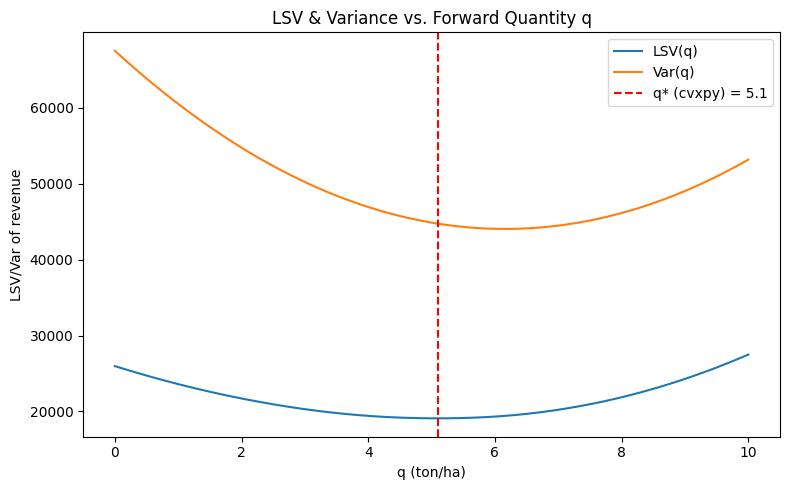


--- Crop: Hybrid ---
Mean Quantity: 4.2226, Mean price: 146.33, Mean revenue: 608.94


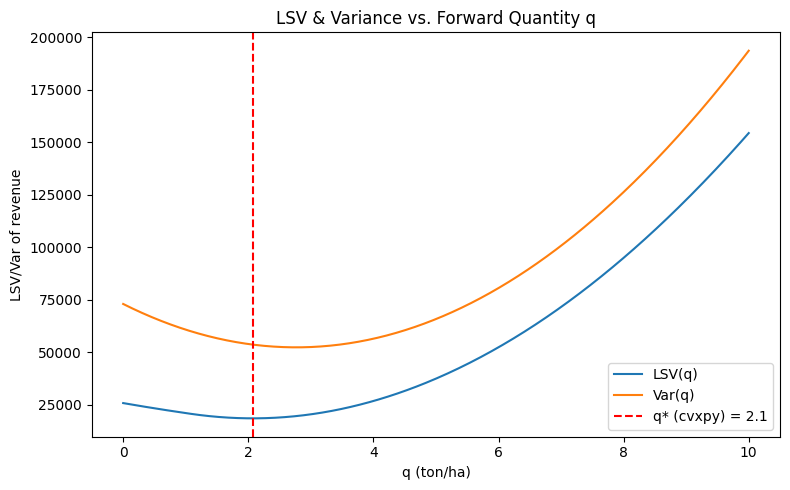


--- Crop: Local ---
Mean Quantity: 3.3359, Mean price: 149.71, Mean revenue: 520.15


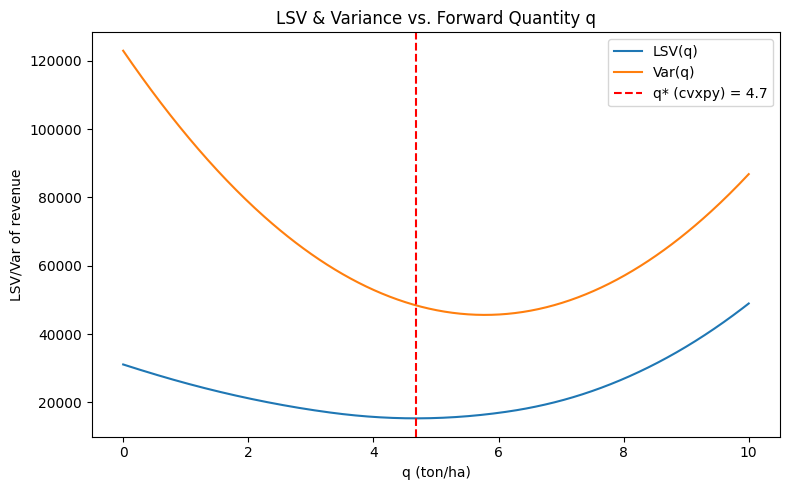

In [41]:
for crop in ["Improved", "Hybrid", "Local"]:
    print(f"\n--- Crop: {crop} ---")

    f = 1.1 * data_df["P_" + crop].mean()  # Example: 10% higher than the average price of the current crop
    m = 0

    P = data_df["P_" + crop].values
    Q = data_df["Q_" + crop].values    

    Pbar  = P.mean()
    PQbar = (P * Q).mean()
    print(f"Mean Quantity: {Q.mean():.4f}, Mean price: {Pbar:.2f}, Mean revenue: {PQbar:.2f}")

    a = PQbar - P * Q     # a_i
    b = Pbar - P          # b_i

    q_star_lsv = CVPI_optimization(a, b, PQbar, Pbar, f, m)
    q_star_var = Variance_optimum(P, Q, f, m, PQbar, Pbar)

    q_grid = np.linspace(0, 10, 400)
    lsv_grid = [LSV(qv, a, b) for qv in q_grid]
    var_grid = [Variance(qv, P, Q, f) for qv in q_grid]

    plt.figure(figsize=(8, 5))
    plt.plot(q_grid, lsv_grid, label="LSV(q)")
    plt.plot(q_grid, var_grid, label="Var(q)")
    plt.axvline(q_star_lsv, color="red", linestyle="--", label=f"q* (cvxpy) = {q_star_lsv   :.1f}")
    plt.xlabel("q (ton/ha)")
    plt.ylabel("LSV/Var of revenue")
    plt.title("LSV & Variance vs. Forward Quantity q")
    plt.legend()
    plt.tight_layout()
    plt.show()